In [155]:
import sympy as sp
import numpy as np
import dg_geometry as DG503

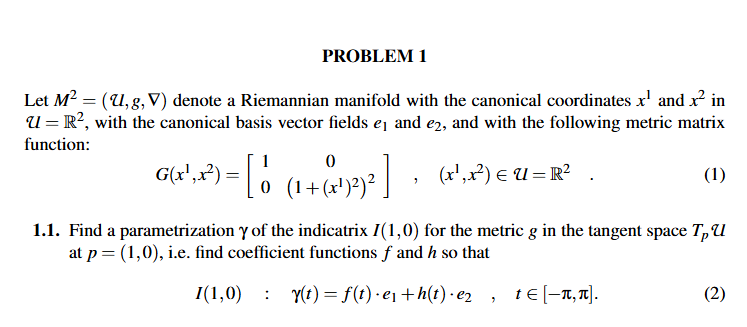

In [156]:
x1, x2, t = sp.symbols('x1 x2 t', real=True)

f = sp.Function('f')(t)
h = sp.Function('h')(t)

Gk = sp.Matrix([[1, 0], [0, (1 + x1**2)**2]])
display(Gk)

Gk_0 = Gk.subs(x1, 1).subs(x2, 0)

V = sp.Matrix([f, h])

I = DG503.g_dot(Gk_0, V, V)
display(I)

V = sp.Matrix([sp.cos(t), sp.sin(t)/2])
display(V)

I = DG503.g_dot(Gk_0, V, V)
display(I)

Matrix([
[1,              0],
[0, (x1**2 + 1)**2]])

f(t)**2 + 4*h(t)**2

Matrix([
[  cos(t)],
[sin(t)/2]])

1

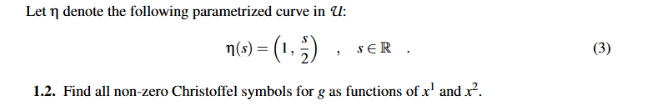

In [157]:
s = sp.symbols('s', real=True)

eta = sp.Matrix([1,s/2])

chris = DG503.christoffel_symbols(Gk, [x1, x2])
display(chris)
display(chris[0,1,1])
display(chris[1,1,0])
display(chris[1,0,1])

{(0, 0, 0): 0,
 (0, 0, 1): 0,
 (0, 1, 0): 0,
 (0, 1, 1): 2*x1/(x1**2 + 1),
 (1, 0, 0): 0,
 (1, 0, 1): 2*x1/(x1**2 + 1),
 (1, 1, 0): -2*x1*(x1**2 + 1),
 (1, 1, 1): 0}

2*x1/(x1**2 + 1)

-2*x1*(x1**2 + 1)

2*x1/(x1**2 + 1)

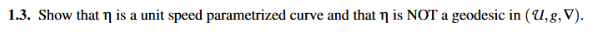

In [158]:
eta_dot = eta.diff(s)
length = DG503.g_norm(Gk.subs({x1: eta[0], x2: eta[1]}), eta_dot)
display(eta_dot)
display(length)

eta_ddot = DG503.curve_acceleration(Gk, eta, s, [x1, x2])
display(eta_ddot)

Matrix([
[  0],
[1/2]])

1

Matrix([
[-1],
[ 0]])

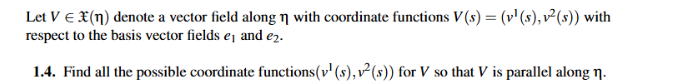

In [159]:
v1 = sp.Function('v1')(s)
v2 = sp.Function('v2')(s)
V = sp.Matrix([v1, v2])
coords = [x1, x2]

cov_gamma = DG503.covariant_derivative_along_curve(Gk, eta,V, s, coords)
display(cov_gamma)

# Define the system of equations (Matrix == 0)
system = [sp.Eq(cov_gamma[0], 0), sp.Eq(cov_gamma[1], 0)]

# Define the functions to solve for
funcs = [v1, v2]

# Solve the system
sol = sp.dsolve(system, funcs)

# Display the result
for s_eq in sol:
    display(sp.simplify(s_eq))

Matrix([
[-2*v2(s) + Derivative(v1(s), s)],
[ v1(s)/2 + Derivative(v2(s), s)]])

Eq(v1(s), 2*C1*sin(s) + 2*C2*cos(s))

Eq(v2(s), C1*cos(s) - C2*sin(s))

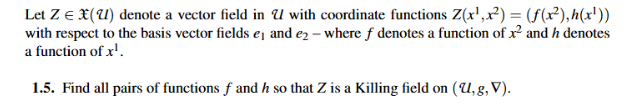

In [160]:
f = sp.Function('f')(x2)
h = sp.Function('h')(x1)

Z = sp.Matrix([f, h])

Lv_g = DG503.lie_derivative_metric(Gk, Z, coords)

display(sp.simplify(Lv_g))
display(sp.simplify(Lv_g[1,1]))

# f can only be 0

display(sp.simplify(Lv_g[1,0]).subs(f, 0))

# and h can be any constant
display(sp.simplify(sp.simplify(Lv_g).subs(f,0).subs(h, sp.Symbol('C'))))

Matrix([
[                                                           0, (x1**2 + 1)**2*Derivative(h(x1), x1) + Derivative(f(x2), x2)],
[(x1**2 + 1)**2*Derivative(h(x1), x1) + Derivative(f(x2), x2),                                       4*x1*(x1**2 + 1)*f(x2)]])

4*x1*(x1**2 + 1)*f(x2)

(x1**2 + 1)**2*Derivative(h(x1), x1) + Derivative(0, x2)

Matrix([
[0, 0],
[0, 0]])

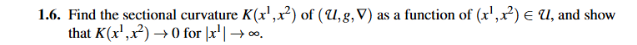

In [161]:
point = sp.Matrix([x1,x2])
V = sp.Matrix([1, 0])
W = sp.Matrix([0, 1])

sec_curv = DG503.sectional_curvature(Gk, point, V, W, coords)
display(sec_curv)
sec_curv_inf = sp.limit(sec_curv, x1, sp.oo)
display(sec_curv_inf)

-2/(x1**2 + 1)

0

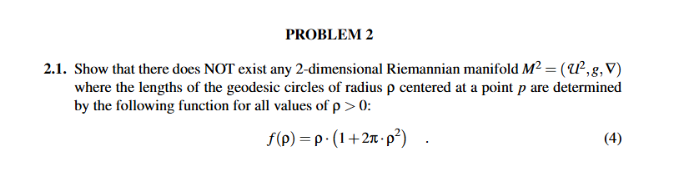

We have 6.29

$K_p = \lim_{\rho \to 0} \left( \frac{3}{\pi} \right) \cdot \left( \frac{2\pi\rho - \mathcal{L}(\rho)}{\rho^3} \right)$

We can input 

$\mathcal{L}(\rho) = f(\rho) = \rho + 2\pi\rho^3$

we can substitute it

$K_p = \frac{3}{\pi} \lim_{\rho \to 0} \frac{2\pi\rho - (\rho + 2\pi\rho^3)}{\rho^3}$

$K_p = \frac{3}{\pi} \lim_{\rho \to 0} \frac{(2\pi - 1)\rho - 2\pi\rho^3}{\rho^3}$

$K_p = \frac{3}{\pi} \lim_{\rho \to 0} \left[ \frac{2\pi - 1}{\rho^2} - 2\pi \right]$

This can easily be seen to go towards infinity and curvature cant be infinite and therefore there is no manifold with geodesic circles with tadius derternined by the function given

In [162]:
rho = sp.symbols('rho', real=True)

L = rho*(1+2*sp.pi*rho**2)

K_p = 3/(sp.pi)*sp.limit((2*sp.pi*rho-L)/rho**3, rho, 0)

display(K_p)

oo

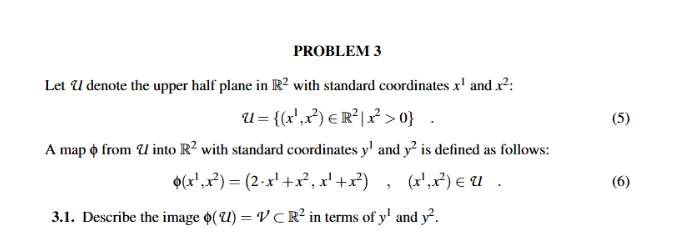

In [163]:
import sympy as sp

y1, y2, x1, x2 = sp.symbols('y1 y2 x1 x2', real=True)

phi = sp.Matrix([2*x1 + x2, x1 + x2])

J = phi.jacobian([x1, x2])
display(J)

det_J = J.det()
display(det_J)

# If sol is the result of solve
sol = sp.solve([sp.Eq(phi[0], y1), sp.Eq(phi[1], y2)], (x1, x2))

# Access the expressions using the symbols as keys
display(sol[x1])
display(sol[x2])

phi_inv = sp.Matrix([sol[x1], sol[x2]])
display(phi_inv)

Matrix([
[2, 1],
[1, 1]])

1

y1 - y2

-y1 + 2*y2

Matrix([
[   y1 - y2],
[-y1 + 2*y2]])

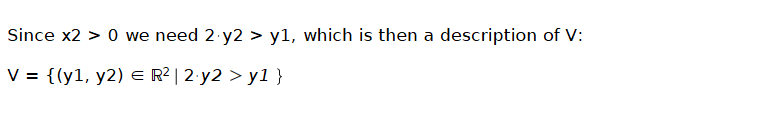

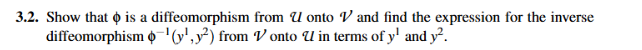

In [164]:
phi_inv = sp.Matrix([sol[x1], sol[x2]])
display(phi_inv)

Matrix([
[   y1 - y2],
[-y1 + 2*y2]])

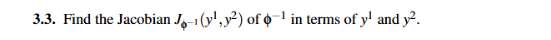

In [165]:
J_inv = phi_inv.jacobian([y1, y2])
display(J_inv)

J_det_inv = J_inv.det()
display(J_det_inv)

J_J_inv = J * J_inv
display(J_J_inv)

Matrix([
[ 1, -1],
[-1,  2]])

1

Matrix([
[1, 0],
[0, 1]])

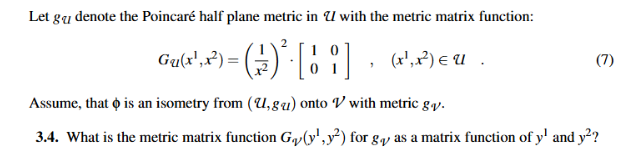

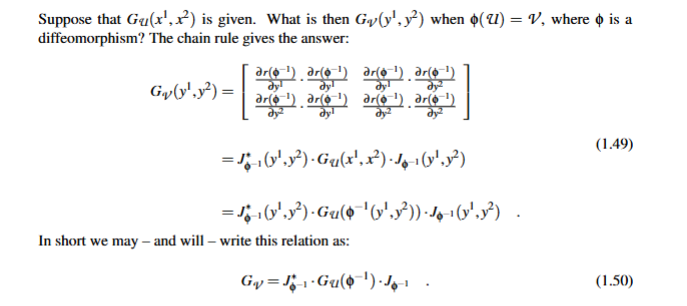

In [166]:
G_u = (1/(x2))**2 * sp.eye(2)
display(G_u)

G_v = J_inv.T * G_u.subs({x1: sol[x1], x2: sol[x2]}) * J_inv
display(G_v)

Matrix([
[x2**(-2),        0],
[       0, x2**(-2)]])

Matrix([
[ 2/(-y1 + 2*y2)**2, -3/(-y1 + 2*y2)**2],
[-3/(-y1 + 2*y2)**2,  5/(-y1 + 2*y2)**2]])

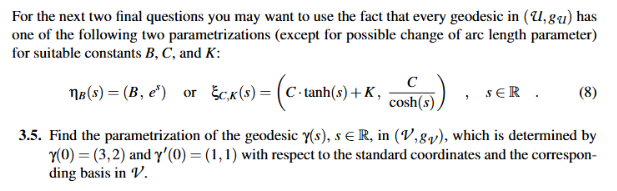

In [167]:
B, s, C, K = sp.symbols('B s C K', real=True)

eta = sp.Matrix([B, sp.E**s])
display(eta)

zeta = sp.Matrix([C*sp.tanh(s) + K, C/sp.cosh(s)])
display(zeta)

Matrix([
[     B],
[exp(s)]])

Matrix([
[C*tanh(s) + K],
[    C/cosh(s)]])

In [168]:
gamma = phi.subs({x1: eta[0], x2: eta[1]})
display(gamma)
gamma_dot = gamma.diff(s)
display(gamma_dot)
sp.solve(sp.Eq(gamma[0].subs(s, 0), 3), (B))

# so B = 0
gamma = gamma.subs(B, 1)
display(gamma)

Matrix([
[2*B + exp(s)],
[  B + exp(s)]])

Matrix([
[exp(s)],
[exp(s)]])

Matrix([
[exp(s) + 2],
[exp(s) + 1]])

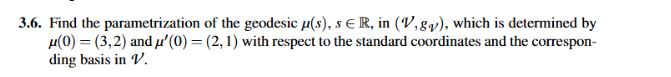

In [176]:
mu = phi.subs({x1: zeta[0], x2: zeta[1]})
display(mu)
mu_dot = mu.diff(s)
display(mu_dot)

C_1 = sp.solve(sp.Eq(mu_dot[0].subs(s, 0), 2),C)[0]

eq3 = sp.Eq(mu[0].subs(s, 0), 3)
display(eq3.subs(C, C_1))

K_1 = sp.solve(eq3.subs(C, C_1), K)[0]
display(K_1)

mu = mu.subs({C: C_1, K: K_1})
display(mu)


Matrix([
[2*C*tanh(s) + C/cosh(s) + 2*K],
[    C*tanh(s) + C/cosh(s) + K]])

Matrix([
[2*C*(1 - tanh(s)**2) - C*sinh(s)/cosh(s)**2],
[  C*(1 - tanh(s)**2) - C*sinh(s)/cosh(s)**2]])

Eq(2*K + 1, 3)

1

Matrix([
[2*tanh(s) + 2 + 1/cosh(s)],
[  tanh(s) + 1 + 1/cosh(s)]])